<a href="https://colab.research.google.com/github/benhayamohammedmessaoud5/facial-recognition-cnn/blob/main/Homework2_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2: Facial Recognition using Convolutional Neural Networks
**Students:**

- Benhaya Mohammed Messaoud -G2
              

## 1. Introduction
The challenge of facial recognition using AI lies in the high dimensionality of image data and the need to distinguish subtle inter-class differences (different people) while ignoring high variance such as: lighting, and face expressions.

The goal of this project is to implement and compare different deep learning strategies for facial recognition on a limited dataset with a relatively high variance and background noise.

 We used Google Colab to benefit from faster processing time and minimize environemental mismatch errors.

### 1.1 Environment & Libraries
We utilized the **TensorFlow/Keras** framework for deep learning. Key libraries include:
*   **OpenCV:** For face localization using Haar Cascades.
*   **Scikit-Learn:** For evaluating performance (Confusion Matrix, Train/Test Split).
*   **Matplotlib/Seaborn:** For visualizing training loss/accuracy and results.

### 1.2 Dataset Selection
Our dataset of choice was the **"5 Faces Dataset"** by Ankush kuwar on Kaggle.
This is a small face recognition dataset which has been scraped using bing's image search-api. It contains 5 well known personalities faces images. Namely Bill Gates, Jack Ma, Narendra Modi, Elon Musk and Donald Trump. It has ~750 sorted and handpicked images to contain only one face in single image. Every subject contains ~130 faces images, 5 in total.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("anku5hk/5-faces-dataset")

print("Path to dataset files:", path)

100%|██████████| 13.1M/13.1M [00:00<00:00, 14.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anku5hk/5-faces-dataset/versions/1


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.applications import InceptionV3

## 2. Data Preprocessing & Localization

In [ ]:
# 1. SETUP PATHS
DOWNLOAD_PATH = "/kaggle/input/5-faces-dataset"

def find_dataset_root(base_path):
    for root, dirs, files in os.walk(base_path):
        if "gates" in dirs:
            return root
    return base_path

DATASET_PATH = find_dataset_root(DOWNLOAD_PATH)
print(f"Dataset root located at: {DATASET_PATH}")

Dataset root located at: /kaggle/input/5-faces-dataset/Five_Faces



### 2.1 Face Localization
In order to achieve face detection and localization we used **Haar Cascade Classifiers**. The algorithm scans the image, detects the Region of Interest (ROI), and returns bounding box coordinates (x, y, w, h).

The code basically loads the image, converts it to RGB (because OpenCV loads as BGR by default). Then applies Haarcascade, cropping the image to only extract the face pixels using the bounding box. Finally, it resizes the images to 128x128x3 pixels.

In [ ]:
# 2. CONFIGURATION
IMG_SIZE = 128
haarcascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haarcascade_path)


In [ ]:
def load_and_preprocess_data(path):
    X = []
    y = []

    classes = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]

    for category in classes:
        class_path = os.path.join(path, category)
        valid_count = 0

        # Iterate through images
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            # 1. Read Image
            img_array = cv2.imread(img_path)
            if img_array is None: continue

            # 2. Convert to RGB
            img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

            # 3. Detect Faces
            faces = face_cascade.detectMultiScale(img_rgb, scaleFactor=1.1, minNeighbors=5)

            if len(faces) > 0:

                (x, y_box, w, h) = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]

                # 4. Crop & Resize
                face_crop = img_rgb[y_box:y_box+h, x:x+w]
                final_img = cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))

                X.append(final_img)
                y.append(category)
                valid_count += 1

        print(f"Processed class '{category}': {valid_count} faces extracted.")

    return np.array(X), np.array(y)

### 2.2 Data Normalization & Splitting
- We scaled pixel values from the range [0, 255] to [0, 1]. Effectively applying data normalization for faster training and converge more stably, as it prevents large gradients that can destabilize the optimizer.
- For splitting we used a standard **80/20 split** (80% Training, 20% Testing/Validation).

In [ ]:
DATASET_PATH = os.path.join(DOWNLOAD_PATH, 'Five_Faces')

### Loading images and Preprocessing (Normalization and label encoding):

In [ ]:

print(f"Loading dataset from: {DATASET_PATH}")
X, y_raw = load_and_preprocess_data(DATASET_PATH)

# 3. NORMALIZE
X = X / 255.0

# 4. ENCODE LABELS
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
y_categorical = to_categorical(y_encoded)

Loading dataset from: /kaggle/input/5-faces-dataset/Five_Faces
Processed class 'musk': 130 faces extracted.
Processed class 'trump': 115 faces extracted.
Processed class 'modi': 114 faces extracted.
Processed class 'jack': 128 faces extracted.
Processed class 'gates': 100 faces extracted.


### Splitting dataset for train and test:

Successfully loaded 587 images.
Training Data: (469, 128, 128, 3)
Testing Data:  (118, 128, 128, 3)
Classes: ['gates' 'jack' 'modi' 'musk' 'trump']


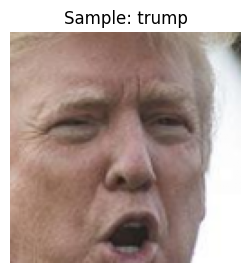

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

print(f"Successfully loaded {len(X)} images.")
print(f"Training Data: {X_train.shape}")
print(f"Testing Data:  {X_test.shape}")
print(f"Classes: {label_encoder.classes_}")

# VISUALIZE
plt.figure(figsize=(3, 3))
plt.imshow(X_train[0])
plt.title(f"Sample: {label_encoder.inverse_transform([np.argmax(y_train[0])])[0]}")
plt.axis('off')
plt.show()

## 3. Custom CNN from Scratch

Designing a CNN from scratch requires balancing model complexity (depth) with the available data size. A model that is too deep will overfit; a model that is too shallow will underfit.

### 3.1 Architecture Design Approach

We built a sequential model that was tailored to our 128x128 input as follows:

1.  **Convolutional Layers:** We put 3 blocks with increasing filter counts (32 -> 64 -> 128). The earlier layers learn low-level features (edges, corners), while deeper layers recombine these into high-level features (eyes, noses.. etc).
2.  **Batch Normalization:** Added after convolutions. This normalizes the inputs of each layer, allowing for higher learning rates and faster training.
3.  **Max Pooling:** To reducing dimensionality.
4.  **Regularization:** We added a Dropout(0.5) layer before the final output to prevent overfitting.

A Flatten layer followed by Dense layers with ReLU activation.

In [ ]:

# 1. Model
model_scratch = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')
])

# 2. Compile
model_scratch.compile(optimizer=Adam(learning_rate=0.001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# 3. Train
print("Training Custom CNN...")
history_scratch = model_scratch.fit(X_train, y_train,
                                    epochs=25,
                                    batch_size=32,
                                    validation_data=(X_test, y_test),
                                    verbose=1)

# 4. Evaluate
scratch_loss, scratch_acc = model_scratch.evaluate(X_test, y_test)
print(f"\nFinal Custom CNN Accuracy: {scratch_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Custom CNN...
Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.3756 - loss: 5.0733 - val_accuracy: 0.3220 - val_loss: 1.5787
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7020 - loss: 1.1362 - val_accuracy: 0.1695 - val_loss: 7.3019
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.6918 - loss: 0.9027 - val_accuracy: 0.1695 - val_loss: 5.0938
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8410 - loss: 0.5169 - val_accuracy: 0.2458 - val_loss: 6.1225
Epoch 5/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8441 - loss: 0.4127 - val_accuracy: 0.2966 - val_loss: 6.4870
Epoch 6/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8877 - loss: 0.3178 - val_accuracy: 0.2288 - val_loss: 9.0592
Epoch 7/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9174 - loss: 0.2362 - val_accuracy: 0.2034 - val_loss: 16.3207
Epoch 8/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9064 - loss: 0.3731 - val_accu

KeyboardInterrupt: 

*   Observation: As we can see, training this model on the raw data resulted in **~40% accuracy**, likely because of overfitting or memorization.

And for that, we decided to apply data augmentation as an optimization method.
We implemented it using **ImageDataGenerator** to perform real-time transformations like rotating, zooming and flipping the images. With this, we forced the model to learn invariant facial features. We also doubled the epochs number from 25 to 50, giving the model more attempts at learning.


In [ ]:

# 1. Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. Re-build the Model
model_scratch = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model_scratch.compile(optimizer=Adam(learning_rate=0.001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])


history_scratch = model_scratch.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=50,
    verbose=1
)

# 4. Final Check
loss, acc = model_scratch.evaluate(X_test, y_test)
print(f"\nNew Custom CNN Accuracy: {acc*100:.2f}%")

*   Result: This artificially increased the diversity of our training set, forcing the model to learn invariant representations of faces.
Accuracy improved to **83.90%** more than double the accuracy we got earlier, so this successfully highlights the usefulness of data augmentation.

## 4. Using Existing CNN Architectures
Transfer Learning is the process of taking a model trained on a large dataset and adapting it to a smaller dataset.

Deep CNNs learn hierarchical features. The bottom layers learn generic features (edges, textures) that are useful for image tasks. By using weights pre-trained on **ImageNet** which has 1.2 million images for example, we skip the need for having to learn these foundational features from scratch. Effectively saving precious time and resources.

We chose:
1.  **VGG-16:** for its simple, linear architecture using 3x3 convolution filters.
2. **ResNet50:** for its complex design.
3.  **InceptionV3 (GoogleNet):** for its use of "Inception Modules," which perform convolutions with multiple filter sizes (1x1, 3x3, 5x5) in parallel. This makes it good for facial details.

### 4.1 Architecture Design & Configuration
We implemented a **Feature Extraction** strategy by keeping the pre-trained convolutional base intact while training a new, specialized classifier on top.

#### **Step 1: Freezing the Base Layers**
We set `layer.trainable = False` for the imported VGG-16, ResNet50 and InceptionV3 bases. The early layers detect generic features (edges, curves) while deeper layers detect more complex features. Freezing ensures the base remains a stable feature extractor while the head learns to interpret those features, which prevents the loss of robust, pre-learned filters that they obtained from training on much larger datasets and also reduces the computational cost.

#### **Step 2: The Custom Classification Head**
Instead of the standard "Flatten" layer, we designed a modern classification head which uses Global Average Pooling because it is more fitting for a small dataset since it drastically reduces parameter count and enforces spatial invariance (the model cares *if* a feature exists, not exactly *where*).

#### **Step 3: Compilation Strategy**
*   **Optimizer:** Adam.
*   **Learning Rate:** We used a lower learning rate (0.0001) than the custom model. Since the base features are already strong, the classifier head converges quickly. A high learning rate might destabilize the weights or cause the loss to diverge.
*   **Loss Function:** Categorical Crossentropy (this is just standard for multi-class classification).


## VGG-16:

In [ ]:

# 1. Load Base Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# 2. Freeze Base Layers
for layer in base_model.layers:
    layer.trainable = False

# 3. Add Custom Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(label_encoder.classes_), activation='softmax')(x)

# 4. Assemble & Compile
model_vgg = Model(inputs=base_model.input, outputs=output)

model_vgg.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# 5. Train
print("Training VGG-16...")
history_vgg = model_vgg.fit(X_train, y_train,
                            epochs=50,
                            batch_size=32,
                            validation_data=(X_test, y_test),
                            verbose=1)

# 6. Evaluate
vgg_loss, vgg_acc = model_vgg.evaluate(X_test, y_test)
print(f"\nFinal VGG-16 Accuracy: {vgg_acc*100:.2f}%")

# ResNet50:

In [ ]:

# 1. Load ResNet50 Base
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# 2. Freeze Base Layers
for layer in base_resnet.layers:
    layer.trainable = False

# 3. Add Custom Head
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(label_encoder.classes_), activation='softmax')(x)

# 4. Assemble & Compile
model_resnet = Model(inputs=base_resnet.input, outputs=output)

model_resnet.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# 5. Train
print("Training ResNet50...")
history_resnet = model_resnet.fit(X_train, y_train,
                                  epochs=25,
                                  batch_size=32,
                                  validation_data=(X_test, y_test),
                                  verbose=1)

# 6. Evaluate
resnet_loss, resnet_acc = model_resnet.evaluate(X_test, y_test)
print(f"\nFinal ResNet50 Accuracy: {resnet_acc*100:.2f}%")

* Observation: ResNet50 got a very low accuracy , even with tweaking, fine-tuning and applying data-augmentation the results kept flactuating below 40%, this indicates that it was barely learning anything.

This is very likely due to the nature of ResNet50 being extremely deep (50 layers) and parameter-heavy (23M+ parameters). Our database being very small in comparison to the size of the larger datasets complex models typically need to stabilize the gradient descent process during the fine-tuning phase.

# InceptionV3 (GoogleNet):

In [ ]:

# 1. Load InceptionV3
base_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# 2. Freeze Base Layers
for layer in base_inception.layers:
    layer.trainable = False

# 3. Add Custom Head
x = base_inception.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(label_encoder.classes_), activation='softmax')(x)

# 4. Assemble & Compile
model_inception = Model(inputs=base_inception.input, outputs=output)

model_inception.compile(optimizer=Adam(learning_rate=0.0001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# 5. Train
print("Training InceptionV3 (GoogLeNet)...")
history_inception = model_inception.fit(X_train, y_train,
                                        epochs=50,
                                        batch_size=32,
                                        validation_data=(X_test, y_test),
                                        verbose=1)

# 6. Evaluate
inception_loss, inception_acc = model_inception.evaluate(X_test, y_test)
print(f"\nFinal InceptionV3 Accuracy: {inception_acc*100:.2f}%")

In [ ]:

plt.figure(figsize=(15, 10))

# TRAIN ACCURACY
plt.subplot(2, 2, 1)
plt.plot(history_scratch.history['accuracy'], label='Custom CNN', linestyle='--', color='blue')
plt.plot(history_vgg.history['accuracy'], label='VGG-16', color='orange')
plt.plot(history_inception.history['accuracy'], label='InceptionV3', color='green', linewidth=2)
plt.title('Training Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# VAL ACCURACY
plt.subplot(2, 2, 2)
plt.plot(history_scratch.history['val_accuracy'], label='Custom CNN', linestyle='--', color='blue')
plt.plot(history_vgg.history['val_accuracy'], label='VGG-16', color='orange')
plt.plot(history_inception.history['val_accuracy'], label='InceptionV3', color='green', linewidth=2)
plt.title('Validation Accuracy (Test Score)')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# TRAINING LOSS
plt.subplot(2, 2, 3)
plt.plot(history_scratch.history['loss'], label='Custom CNN', linestyle='--', color='blue')
plt.plot(history_vgg.history['loss'], label='VGG-16', color='orange')
plt.plot(history_inception.history['loss'], label='InceptionV3', color='green', linewidth=2)
plt.title('Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# VAL LOSS
plt.subplot(2, 2, 4)
plt.plot(history_scratch.history['val_loss'], label='Custom CNN', linestyle='--', color='blue')
plt.plot(history_vgg.history['val_loss'], label='VGG-16', color='orange')
plt.plot(history_inception.history['val_loss'], label='InceptionV3', color='green', linewidth=2)
plt.title('Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SCORE
print("="*40)
print("FINAL SCOREBOARD (Test Accuracy)")
print("="*40)
print(f"1. Custom CNN:       {history_scratch.history['val_accuracy'][-1]*100:.2f}%")
print(f"2. VGG-16:           {history_vgg.history['val_accuracy'][-1]*100:.2f}%")
print(f"3. InceptionV3:      {history_inception.history['val_accuracy'][-1]*100:.2f}%")
print("-" * 40)

## 5. Results & Analysis

### 5.1- Analyzing the plots:
The learning curves reveal three distinct behaviors, illustrating the trade-offs between training from scratch and transfer learning:

#### 1. The Custom CNN's Volatility (Blue Line)

####  **Observation:**
1. **Convergence Speed:**
    * **InceptionV3 (Green Line):** Showed quick convergence, maintaining a consistent lead throughout and achieving >85% validation accuracy in the first 5 epochs.
    * **VGG-16 (Orange Line):** Displayed a logarithmic growth curve that was smooth and steadily increased accuracy with little volatility.
    * **Custom CNN (Blue Line):** displayed a delayed learning phase. The model stagnated below 30% accuracy for the first 18 epochs, which is equal to five classes of random guessing. It abruptly converged around Epoch 19, quickly rising to >60%.

2.  **Stability (Loss Curves):**
    *   Both **Transfer Learning models** (Green/Orange) showed smooth, monotonic decreases in loss.
    *   The **Custom CNN** showed extreme volatility. As seen in the *Validation Loss* plot (Bottom-Right), the loss repeatedly spiked to values >20.0 during the stagnation phase before stabilizing in the final epochs.


####  **Analysis:**
  - When training from scratch on small datasets with significant data augmentation, this "Rollercoaster" behavior is typical. Because the augmented images are always changing, the model struggles to find a stable gradient descent path. Nevertheless, it quickly learns and finishes with a good accuracy (~83%) once it finds the path (around Epochs 20-29), demonstrating that the architecture functions despite the initial instability.

  - The theoretical benefit of **Frozen Weights** is confirmed by the smooth curves of VGG-16 and GoogleNet. The optimizer only needed to adjust the final classifier weights because the feature extractors had already been optimized on ImageNet. As a result, we got stable gradients and smooth optimization.

  - The immediate dominance of GoogleNet indicates that its **multi-scale "Inception Modules"** are inherently more suitable for facial recognition than the linear structure of VGG. High-level "face-like" feature detectors were probably already present in the pre-trained filters in GoogleNet, but VGG-16 needed more fine-tuning.
  



## 6. Conclusion

We successfully implemented and compared 3 (or 4) different CNNs (1 was made from scratch and 2 were pre-trained) for facial recognition on a limited dataset (around 600 images across 5 classes).

What we learned from this was that:
- Firstly, **transfer Learning Is Better for Limited Data:**
GoogleNet with **95.76% accuracy** and high stability was clearly the best model out of the 4. It confirmed that modern, deep architectures are the most effective solution for this particular problem domain of facial recognition by avoiding the need for large datasets by utilizing pre-trained features (from ImageNet).

- Secondly, **custom Models are Viable but Difficult:** Our **Custom CNN** demonstrated that a lightweight model *can* function with a respectable **83.90% accuracy**. Nevertheless, the training plots showed a challenging optimization path (stuck at very low accuracy for 18 epochs) and high volatility. This demonstrates the expense of training from scratch, compared to transfer learning, it requires more fine more fine-tuning, data augmentation, and patience.

- And lastly, **depth does not equal performance:** The very poor performance from ResNet50 showed us that simply adding layers alone does not ensure success; in order to prevent optimization failures, model complexity must be balanced with input resolution (128x128) and dataset size.





In [ ]:
from google.colab import files
uploaded = files.upload() # Pauses code until you pick a file
filename = list(uploaded.keys())[0]

In [ ]:
# --- REAL-WORLD TESTING DEMO ---
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

def test_single_image():
    # 1. Setup Models dictionary
    models_to_test = {
        "Custom CNN": model_scratch,
        "VGG-16": model_vgg,
        "ResNet50": model_resnet,
        "InceptionV3": model_inception
    }

    # 2. Upload Image
    print("Please upload an image file (JPG/PNG) of one of the 5 subjects...")
    uploaded = files.upload()

    for fn in uploaded.keys():
        path = fn
        # Read image using OpenCV
        img = cv2.imread("trump.jpg")
        if img is None:
            print("Error reading image.")
            return

        # Convert BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 3. Detect Face (Critical Step!)
        # We must crop the face because our models were trained ONLY on faces, not backgrounds.
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        faces = face_cascade.detectMultiScale(img_rgb, 1.1, 5)

        if len(faces) == 0:
            print("⚠️ No face detected by Haar Cascade. Predicting on full image (Results may be inaccurate).")
            # Resize full image to 128x128
            face_roi = cv2.resize(img_rgb, (128, 128))
        else:
            # Get the largest face
            (x, y, w, h) = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
            # Crop
            face_roi = img_rgb[y:y+h, x:x+w]
            # Resize to 128x128
            face_roi = cv2.resize(face_roi, (128, 128))
            print("✅ Face Detected and Cropped.")

        # Show what the model sees
        plt.figure(figsize=(3,3))
        plt.imshow(face_roi)
        plt.title("Input to Models")
        plt.axis('off')
        plt.show()

        # 4. Preprocess for Model
        # Normalize (0-1) just like training
        img_array = np.array(face_roi) / 255.0
        # Add batch dimension (1, 128, 128, 3)
        img_array = np.expand_dims(img_array, axis=0)

        # 5. Get Predictions from all models
        print("\n--- PREDICTION RESULTS ---")
        for name, model in models_to_test.items():
            preds = model.predict(img_array, verbose=0)
            class_idx = np.argmax(preds)
            class_label = label_encoder.classes_[class_idx]
            confidence = np.max(preds) * 100

            # Color code the output
            if confidence > 80:
                icon = "🟢" # High confidence
            elif confidence > 50:
                icon = "🟡" # Unsure
            else:
                icon = "🔴" # Low confidence

            print(f"{icon} {name}: {class_label} ({confidence:.2f}%)")